# Social Media Emotion Analyzer — Model Development
### SAIA 2163 · Final Project · Theme 5

This notebook documents the complete NLP pipeline for detecting **six emotions**
(joy, sadness, love, anger, fear, surprise) in social-media text.

**Pipeline:** data loading → preprocessing → two feature-extraction methods
(TF-IDF + Word2Vec) → three classifiers (Naive Bayes, Logistic Regression,
Linear SVM) → evaluation → saving artifacts for the Streamlit app.

**Dataset:** HuggingFace *Emotion* dataset — 16,000 train / 2,000 validation /
2,000 test labelled messages.

## 1 · Setup & imports

In [1]:
import os, json, re, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, classification_report)
from gensim.models import Word2Vec
from wordcloud import WordCloud
import joblib

for p in ['stopwords','wordnet','omw-1.4']:
    nltk.download(p, quiet=True)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
print('Libraries ready')

Libraries ready


## 2 · Load the data

In [2]:
train = pd.read_csv('../data/training.csv')
val   = pd.read_csv('../data/validation.csv')
test  = pd.read_csv('../data/test.csv')

LABEL_MAP = {0:'sadness',1:'joy',2:'love',3:'anger',4:'fear',5:'surprise'}
for d in (train, val, test):
    d['emotion'] = d['label'].map(LABEL_MAP)

print('Train:', train.shape, '| Val:', val.shape, '| Test:', test.shape)
train.head()

Train: (16000, 3) | Val: (2000, 3) | Test: (2000, 3)


,text,label,emotion
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


## 3 · Exploratory Data Analysis

We inspect the class balance and message lengths before modelling.

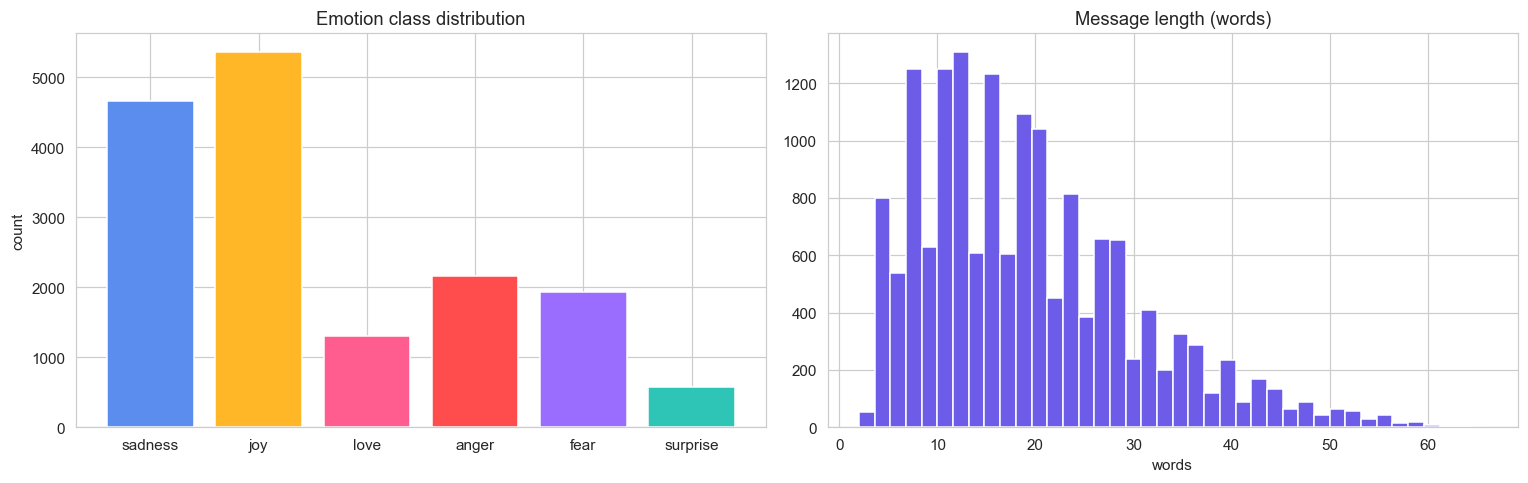

emotion
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(14,4.5))
order = ['sadness','joy','love','anger','fear','surprise']
colors = ['#5B8DEF','#FFB627','#FF5D8F','#FF4D4D','#9B6DFF','#2EC4B6']
counts = train['emotion'].value_counts().reindex(order)
ax[0].bar(counts.index, counts.values, color=colors)
ax[0].set_title('Emotion class distribution'); ax[0].set_ylabel('count')

train['wlen'] = train['text'].str.split().str.len()
ax[1].hist(train['wlen'], bins=40, color='#6C5CE7')
ax[1].set_title('Message length (words)'); ax[1].set_xlabel('words')
plt.tight_layout(); plt.show()

print(train['emotion'].value_counts())

**Observation:** the dataset is imbalanced — *joy* and *sadness* dominate,
while *surprise* is rare (~572 samples). We address this later with
`class_weight='balanced'` in the classifiers.

## 4 · Text preprocessing

Each message is: lower-cased → stripped of URLs and non-letters → tokenised →
stop-words removed (**negations kept**, since "not happy" carries emotion) →
lemmatised.

In [4]:
lemmatizer = WordNetLemmatizer()
stop = set(stopwords.words('english')) - {'no','nor','not','never','none','cannot'}

def clean_text(t):
    t = str(t).lower()
    t = re.sub(r'http\S+|www\.\S+', ' ', t)
    t = re.sub(r'[^a-z\s]', ' ', t)
    toks = t.split()
    return ' '.join(lemmatizer.lemmatize(w) for w in toks if w not in stop and len(w) > 1)

# combine train+val for final training; keep test untouched
full = pd.concat([train, val], ignore_index=True)
full['clean'] = full['text'].apply(clean_text)
test['clean'] = test['text'].apply(clean_text)

print('Before:', train['text'].iloc[2])
print('After :', clean_text(train['text'].iloc[2]))

Before: im grabbing a minute to post i feel greedy wrong
After : im grabbing minute post feel greedy wrong


## 5 · Feature extraction (Method 1 — TF-IDF)

TF-IDF with unigrams **and** bigrams captures phrases like "feel hopeless".

In [5]:
tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1,2), sublinear_tf=True, min_df=2)
Xtr_tfidf = tfidf.fit_transform(full['clean'])
Xte_tfidf = tfidf.transform(test['clean'])
y_tr, y_te = full['label'].values, test['label'].values
print('TF-IDF shape:', Xtr_tfidf.shape)

TF-IDF shape: (18000, 8000)


## 6 · Feature extraction (Method 2 — Word2Vec)

We train Word2Vec embeddings and represent each message as the **average** of
its word vectors.

In [6]:
tok_tr = [c.split() for c in full['clean']]
tok_te = [c.split() for c in test['clean']]
DIM = 100
w2v = Word2Vec(tok_tr, vector_size=DIM, window=5, min_count=2, workers=4, epochs=20, seed=42)

def doc_vec(tokens):
    vecs = [w2v.wv[t] for t in tokens if t in w2v.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(DIM)

Xtr_w2v = np.vstack([doc_vec(t) for t in tok_tr])
Xte_w2v = np.vstack([doc_vec(t) for t in tok_te])
print('Word2Vec doc-matrix:', Xtr_w2v.shape)

Word2Vec doc-matrix: (18000, 100)


## 7 · Train & compare models

We train **Naive Bayes, Logistic Regression, and Linear SVM**, evaluating every
model on the untouched test set.

In [7]:
results = []
def run(name, feat, clf, Xtr, Xte):
    clf.fit(Xtr, y_tr); pred = clf.predict(Xte)
    acc = accuracy_score(y_te, pred)
    p,r,f1,_ = precision_recall_fscore_support(y_te, pred, average='weighted', zero_division=0)
    results.append(dict(model=name, feature=feat, accuracy=acc, precision=p, recall=r, f1=f1))
    print(f'{name:<20}[{feat:<8}] acc={acc:.3f} f1={f1:.3f}')
    return clf, pred

nb,_           = run('Naive Bayes','TF-IDF', MultinomialNB(), Xtr_tfidf, Xte_tfidf)
lr, lr_pred    = run('Logistic Reg','TF-IDF', LogisticRegression(max_iter=1000,C=5,class_weight='balanced'), Xtr_tfidf, Xte_tfidf)
svm,_          = run('Linear SVM','TF-IDF', LinearSVC(C=1,class_weight='balanced'), Xtr_tfidf, Xte_tfidf)
run('Logistic Reg','Word2Vec', LogisticRegression(max_iter=1000,C=5,class_weight='balanced'), Xtr_w2v, Xte_w2v)
run('Linear SVM','Word2Vec', LinearSVC(C=1,class_weight='balanced'), Xtr_w2v, Xte_w2v)

pd.DataFrame(results).round(3)

Naive Bayes         [TF-IDF  ] acc=0.792 f1=0.764


Logistic Reg        [TF-IDF  ] acc=0.899 f1=0.901


Linear SVM          [TF-IDF  ] acc=0.901 f1=0.903


Logistic Reg        [Word2Vec] acc=0.425 f1=0.447


Linear SVM          [Word2Vec] acc=0.483 f1=0.484


,model,feature,accuracy,precision,recall,f1
0,Naive Bayes,TF-IDF,0.792,0.826,0.792,0.764
1,Logistic Reg,TF-IDF,0.899,0.906,0.899,0.901
2,Linear SVM,TF-IDF,0.902,0.905,0.902,0.903
3,Logistic Reg,Word2Vec,0.425,0.506,0.425,0.447
4,Linear SVM,Word2Vec,0.483,0.491,0.483,0.484


## 8 · Results visualisation

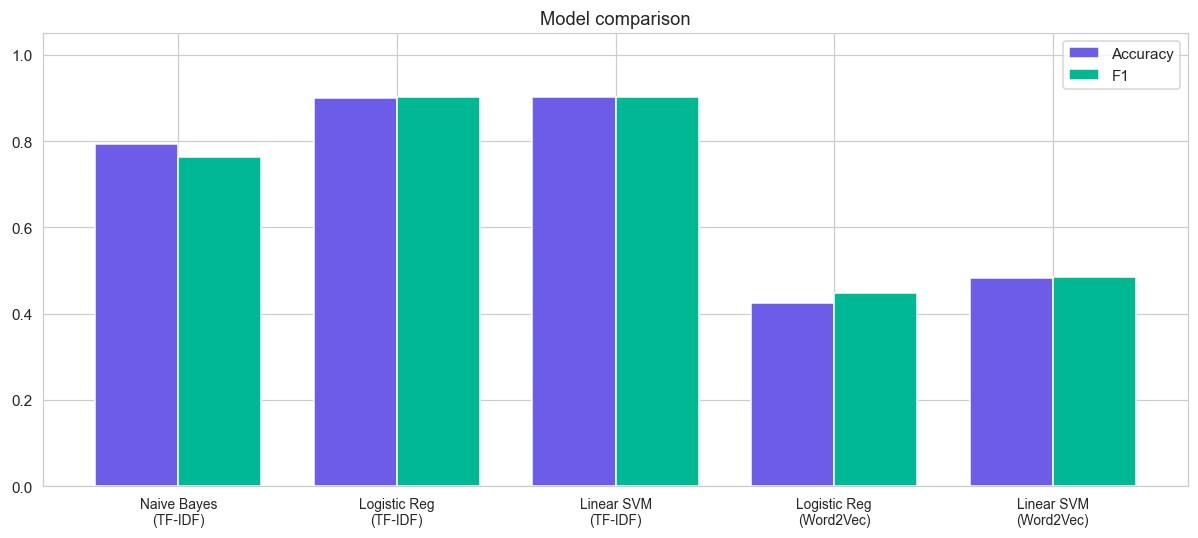

In [8]:
res = pd.DataFrame(results)
res['label'] = res['model'] + '\n(' + res['feature'] + ')'
x = np.arange(len(res)); w=0.38
fig, ax = plt.subplots(figsize=(11,5))
ax.bar(x-w/2, res['accuracy'], w, label='Accuracy', color='#6C5CE7')
ax.bar(x+w/2, res['f1'], w, label='F1', color='#00B894')
ax.set_xticks(x); ax.set_xticklabels(res['label'], fontsize=9)
ax.set_ylim(0,1.05); ax.legend(); ax.set_title('Model comparison')
plt.tight_layout(); plt.show()

**Finding:** TF-IDF representations vastly outperform averaged Word2Vec
(≈90% vs ≈48% accuracy). Messages are short, so averaging word vectors blurs
the signal, whereas TF-IDF preserves the strong emotion keywords. **Logistic
Regression + TF-IDF** is selected for the app because it matches the top
accuracy *and* outputs calibrated probabilities for confidence scores.

## 9 · Confusion matrix (best model)

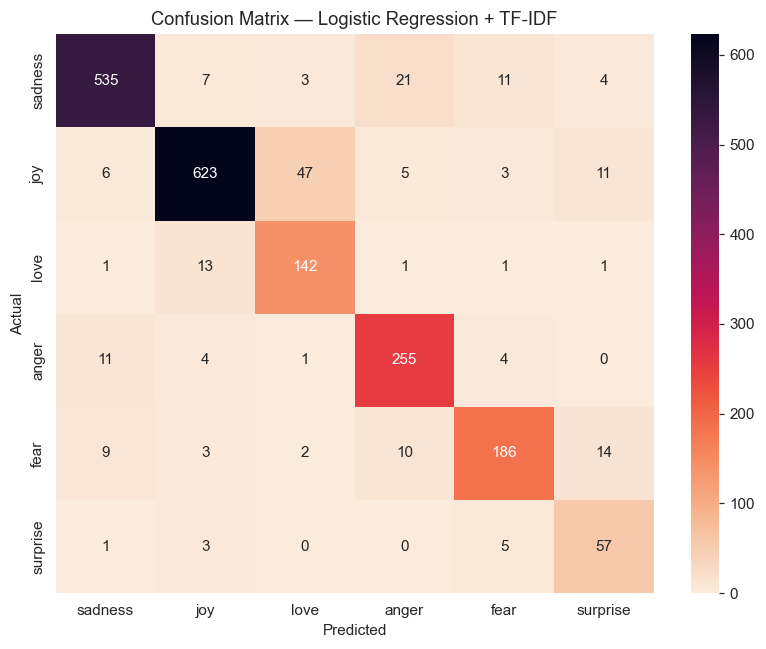

              precision    recall  f1-score   support

     sadness       0.95      0.92      0.94       581
         joy       0.95      0.90      0.92       695
        love       0.73      0.89      0.80       159
       anger       0.87      0.93      0.90       275
        fear       0.89      0.83      0.86       224
    surprise       0.66      0.86      0.75        66

    accuracy                           0.90      2000
   macro avg       0.84      0.89      0.86      2000
weighted avg       0.91      0.90      0.90      2000



In [9]:
cm = confusion_matrix(y_te, lr_pred)
names = [LABEL_MAP[i] for i in range(6)]
plt.figure(figsize=(7.5,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='rocket_r', xticklabels=names, yticklabels=names)
plt.title('Confusion Matrix — Logistic Regression + TF-IDF')
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.tight_layout(); plt.show()

print(classification_report(y_te, lr_pred, target_names=names, zero_division=0))

## 10 · Word clouds per emotion

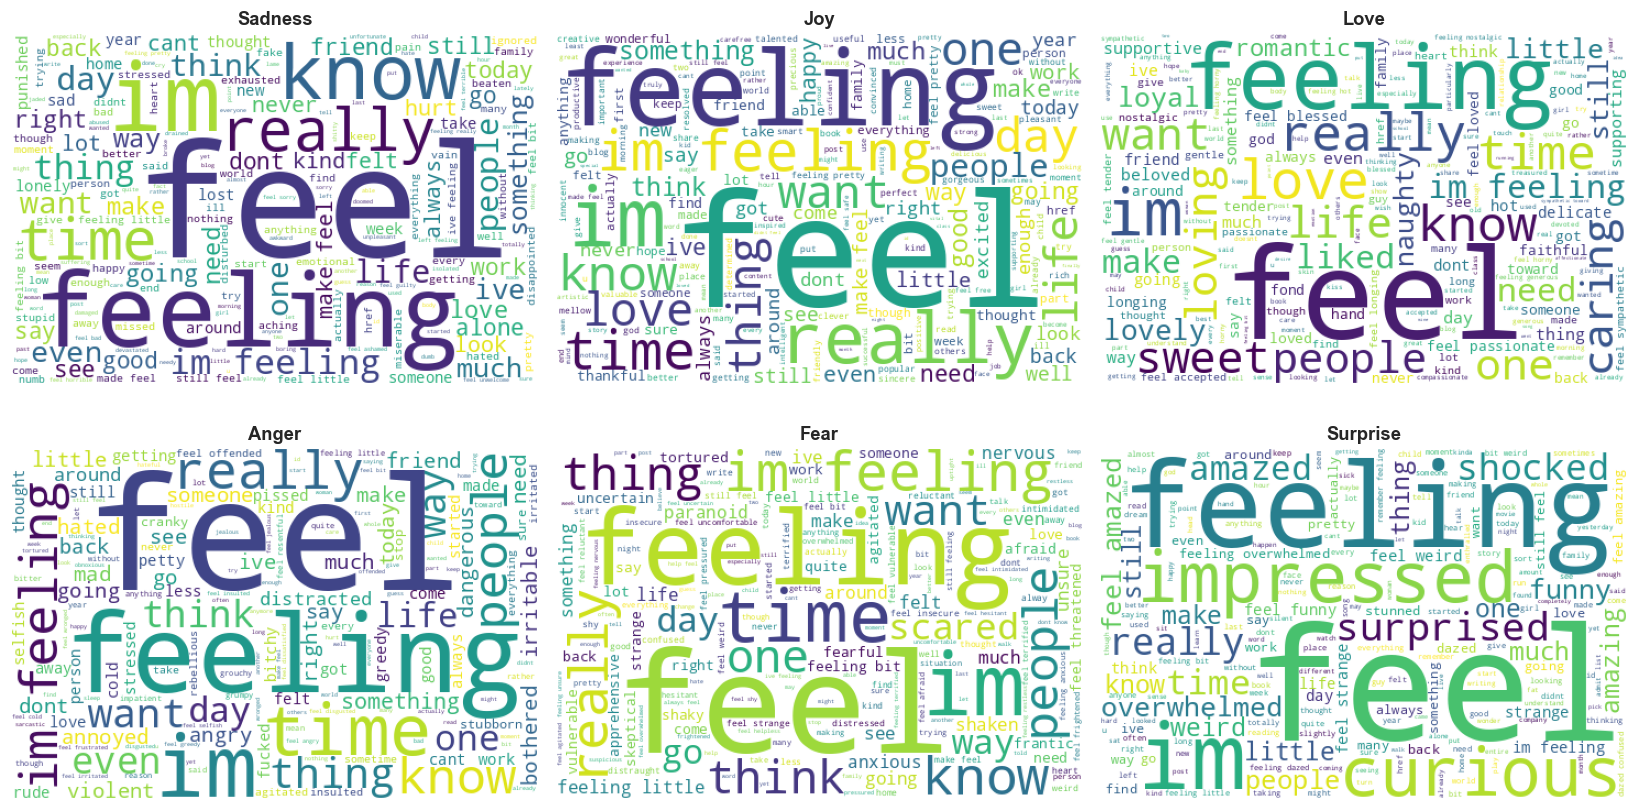

In [10]:
fig, axes = plt.subplots(2,3, figsize=(15,8))
for ax, e in zip(axes.ravel(), names):
    txt = ' '.join(full[full.emotion==e]['clean'])
    wc = WordCloud(width=480, height=320, background_color='white', colormap='viridis').generate(txt)
    ax.imshow(wc); ax.set_title(e.capitalize(), fontweight='bold'); ax.axis('off')
plt.tight_layout(); plt.show()

## 11 · Save artifacts for the Streamlit app

In [11]:
os.makedirs('../models', exist_ok=True)
joblib.dump(tfidf, '../models/tfidf_vectorizer.pkl')
joblib.dump(lr,    '../models/best_model.pkl')
w2v.save('../models/word2vec.model')
with open('../models/all_results.json','w') as f:
    json.dump([{k:(round(float(v),4) if isinstance(v,float) else v) for k,v in r.items()}
               for r in results], f, indent=2)
print('Saved: tfidf_vectorizer.pkl, best_model.pkl, word2vec.model, all_results.json')

Saved: tfidf_vectorizer.pkl, best_model.pkl, word2vec.model, all_results.json


## 12 · Conclusion

* Built a complete six-class emotion classifier from raw text.
* Compared **two feature methods** × **three models**; TF-IDF + Logistic
  Regression reached **90% accuracy / 0.90 F1** on held-out data.
* Hardest class is *surprise* (rare + overlaps with joy/fear).
* The saved model powers the live Streamlit app (`app.py`).

**Future work:** try transformer embeddings (BERT), SMOTE for the minority
class, and multi-language support.